In [1]:
"""Compare five parameter regimes side by side.

Edit shared run settings below, then tweak individual regimes in the next cell.
Each regime produces two figures (mean ± 95% CI across seeds):
  • full dashboard — fleet, stock, network, wealth
  • role dynamics — producer/scrounger mix, λ diversity, role switching

Loss aversion λ evolves per-agent (bounds [1, 5]); σ controls mutation at reproduction.
Role switch rate = share of boats that changed produce/scrounge role since last step.
"""

# Shared run settings
N_SEEDS = 5
BASE_SEED = 42
STEPS = 1000

# Default parameters (regimes override individual fields)
DEFAULTS = dict(
    width=50,
    height=50,
    n_agents=80,
    v=3,
    r=0.1,
    q=0.3,
    c=0.05,
    beta=2.0,
    C_birth=2.0,
    sigma=0.5,
    finders_share=0.5,
    patch_scale=0.1,
)

In [2]:
# Five regimes to compare — edit overrides per row
REGIMES = [
    {
        "name": "1 · Baseline",
        "desc": "Default parameters — λ co-evolves with PS network",
        "overrides": {},
    },
    {
        "name": "2 · Noisy roles",
        "desc": "Low β → stochastic produce/scrounge switching",
        "overrides": {"beta": 0.5},
    },
    {
        "name": "3 · Scrounger paradise",
        "desc": "Low finder share f — joiners capture most of the catch",
        "overrides": {"finders_share": 0.2},
    },
    {
        "name": "4 · Overfishing pressure",
        "desc": "Slow regrowth + high catchability — stressed stock",
        "overrides": {"r": 0.05, "q": 0.5},
    },
    {
        "name": "5 · Fast λ evolution",
        "desc": "High mutation σ — rapid spread of loss-aversion traits",
        "overrides": {"sigma": 1.0},
    },
]

for regime in REGIMES:
    regime["params"] = {**DEFAULTS, **regime["overrides"]}
    print(f"{regime['name']}: {regime['desc']}")
    if regime["overrides"]:
        print(f"  overrides: {regime['overrides']}")

1 · Baseline: Default parameters — λ co-evolves with PS network
2 · Noisy roles: Low β → stochastic produce/scrounge switching
  overrides: {'beta': 0.5}
3 · Scrounger paradise: Low finder share f — joiners capture most of the catch
  overrides: {'finders_share': 0.2}
4 · Overfishing pressure: Slow regrowth + high catchability — stressed stock
  overrides: {'r': 0.05, 'q': 0.5}
5 · Fast λ evolution: High mutation σ — rapid spread of loss-aversion traits
  overrides: {'sigma': 1.0}


In [3]:
import importlib

import matplotlib.pyplot as plt
import numpy as np

import model as model_module

importlib.reload(model_module)
from model import FishingModel

DASHBOARD_METRICS = [
    "Boats",
    "Bankruptcies",
    "Mean fish density",
    "Mean lambda",
    "Std lambda",
    "Network mean degree",
    "Network LCC fraction",
    "Wealth Gini",
]

ROLE_METRICS = ["Producer rate", "Scrounge rate", "Std lambda", "Role switch rate"]

_probe = FishingModel(**REGIMES[0]["params"], rng=BASE_SEED)
EXPECTED_COLS = _probe.datacollector.get_model_vars_dataframe().columns.tolist()
missing = [m for m in DASHBOARD_METRICS + ROLE_METRICS if m not in EXPECTED_COLS]
if missing:
    raise ValueError(
        f"Model missing columns {missing}. Restart kernel and re-run from the top. "
        f"Available: {EXPECTED_COLS}"
    )

results = {}
for regime in REGIMES:
    runs = []
    for i in range(N_SEEDS):
        m = FishingModel(**regime["params"], rng=BASE_SEED + i)
        for _ in range(STEPS):
            m.step()
        runs.append(m.datacollector.get_model_vars_dataframe())
    results[regime["name"]] = runs
    print(f"{regime['name']}: {N_SEEDS} runs × {STEPS} steps done")

print("Columns:", results[REGIMES[0]["name"]][0].columns.tolist())

1 · Baseline: 5 runs × 1000 steps done
2 · Noisy roles: 5 runs × 1000 steps done
3 · Scrounger paradise: 5 runs × 1000 steps done
4 · Overfishing pressure: 5 runs × 1000 steps done
5 · Fast λ evolution: 5 runs × 1000 steps done
Columns: ['Boats', 'Bankruptcies', 'Mean fish density', 'Mean lambda', 'Std lambda', 'Producer rate', 'Scrounge rate', 'Role switch rate', 'Network mean degree', 'Network LCC fraction', 'Network components', 'Wealth Gini']


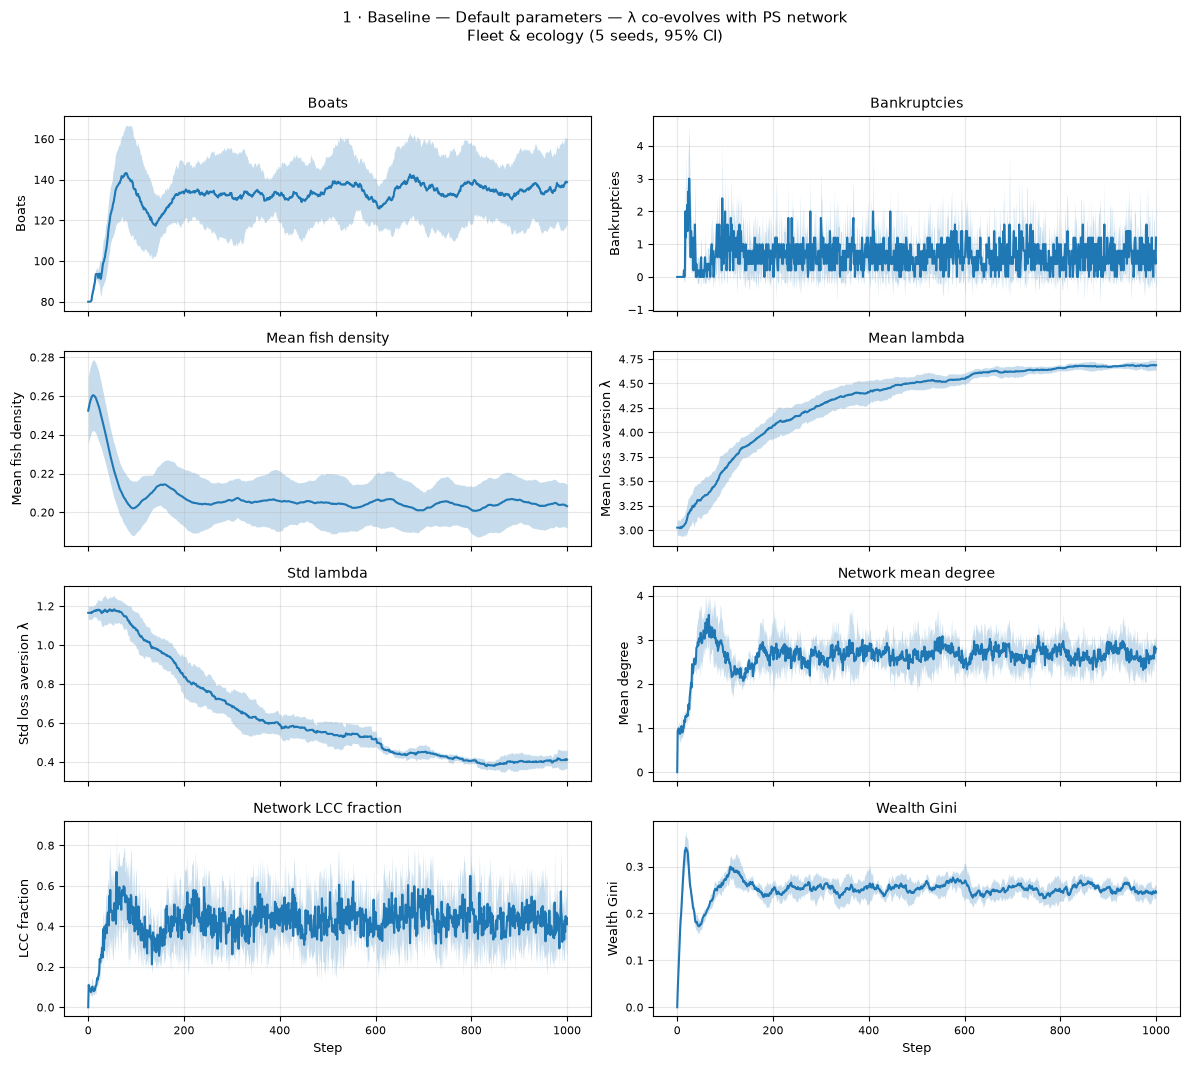

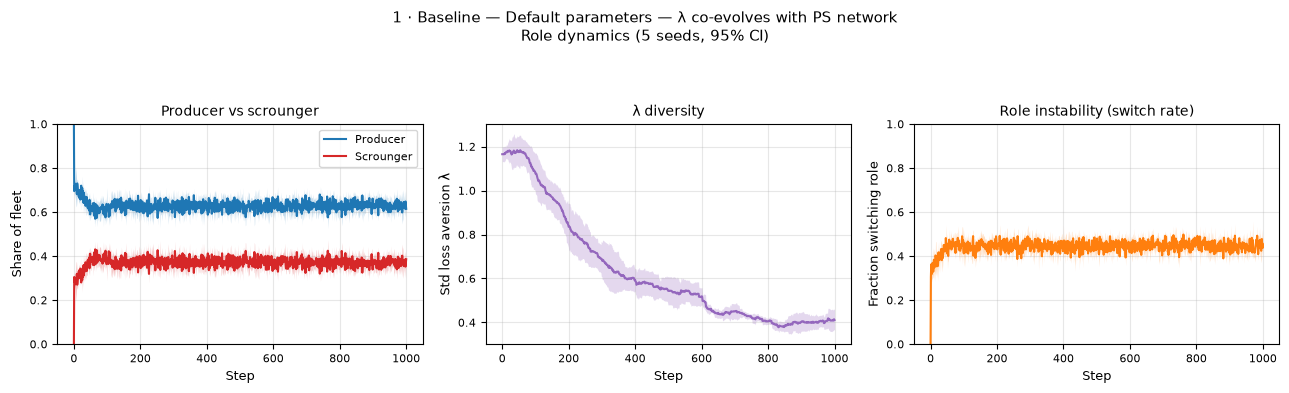

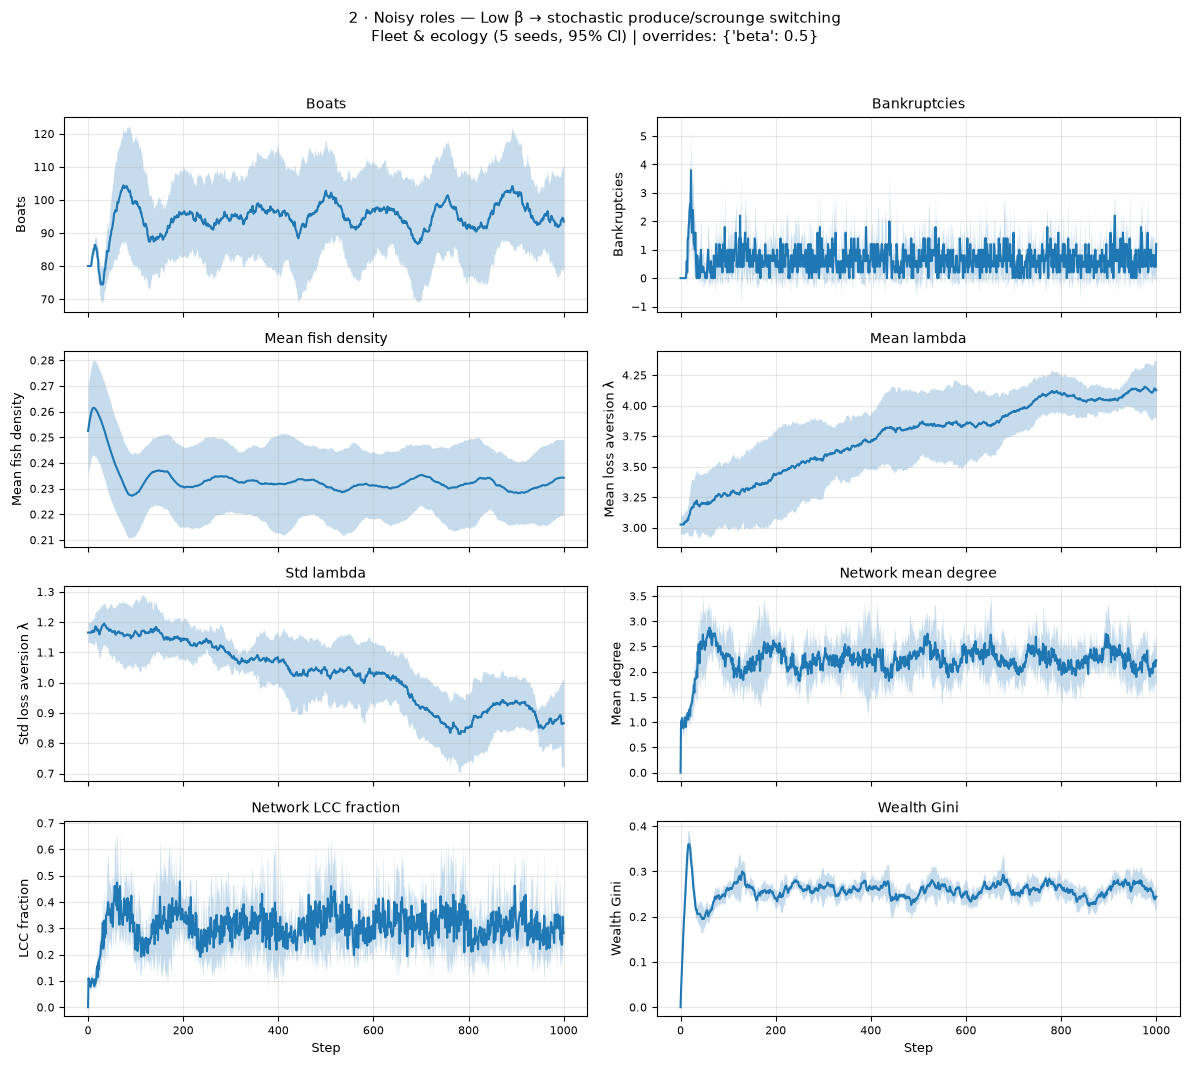

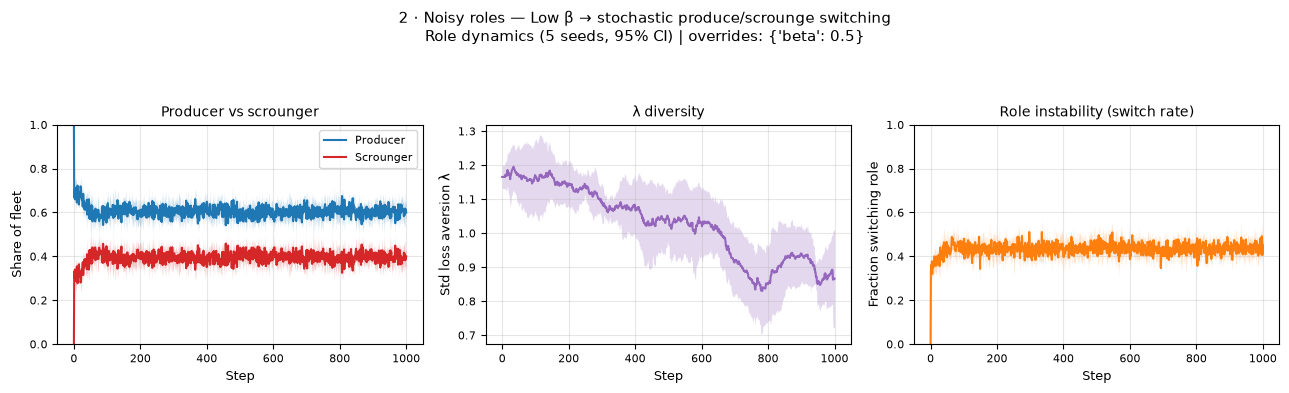

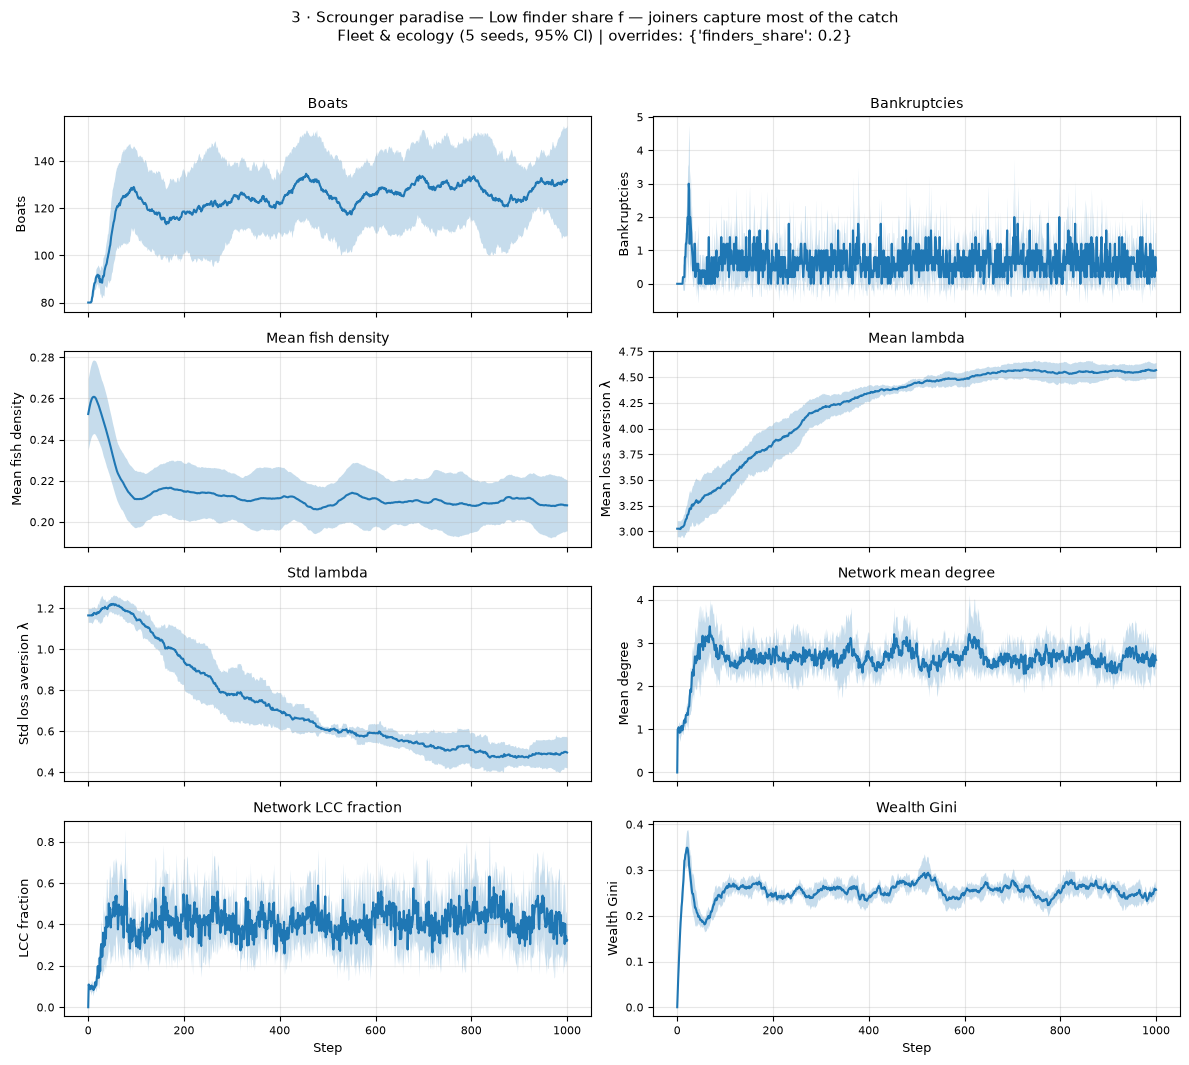

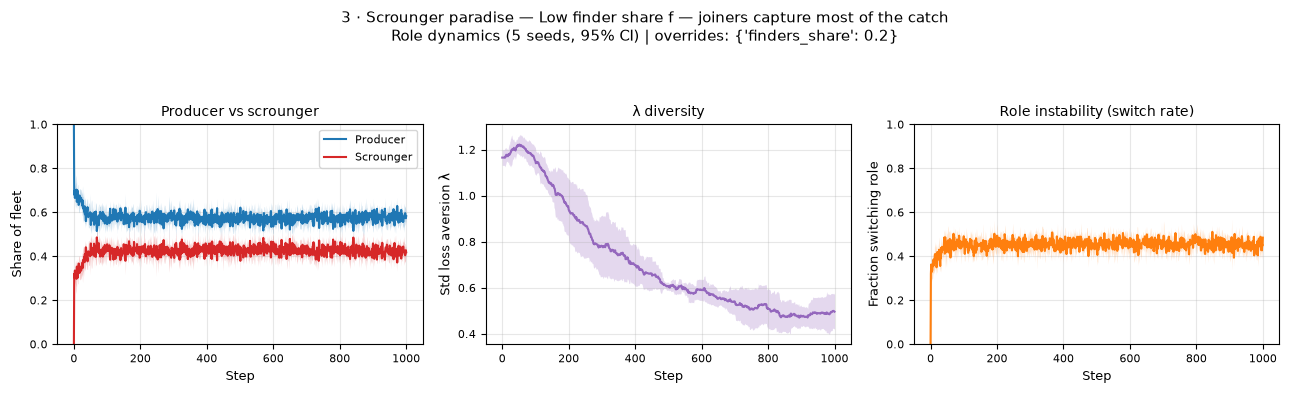

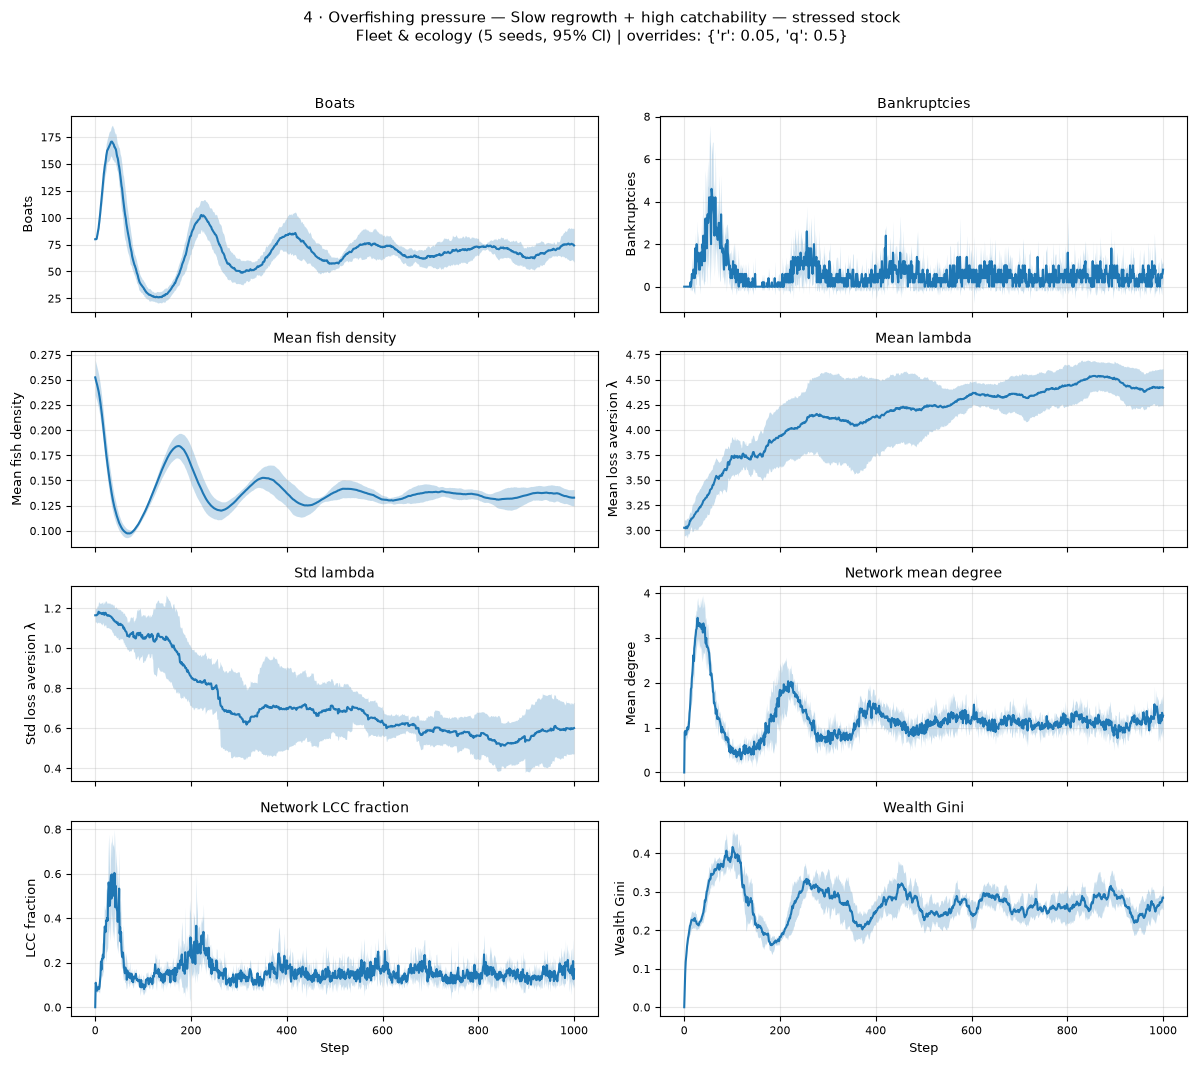

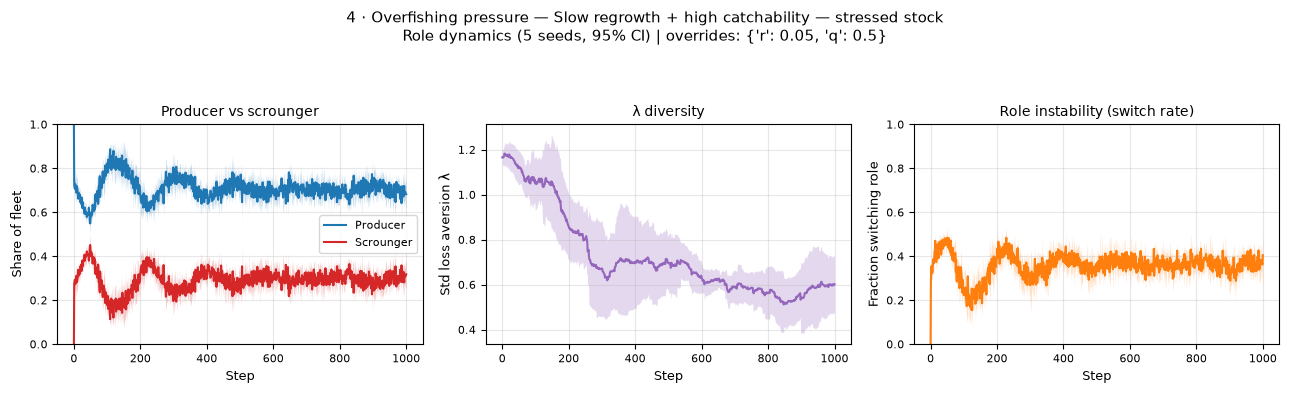

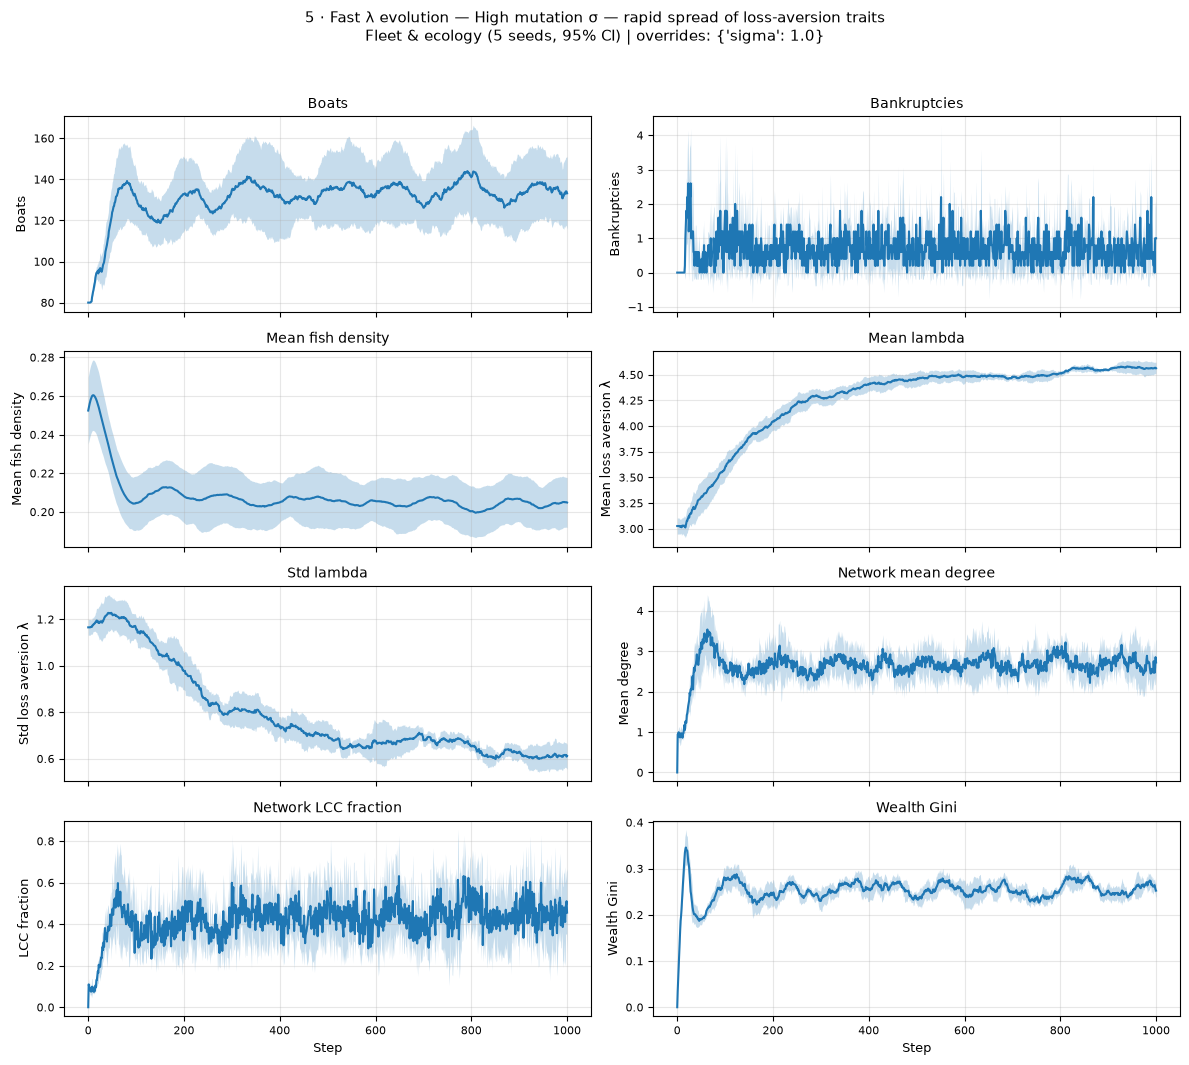

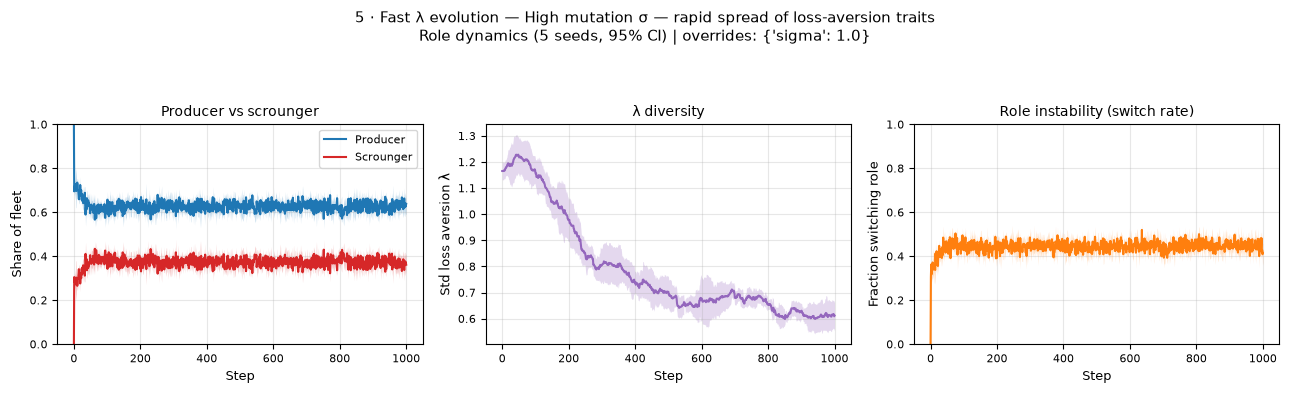

In [4]:
def _aggregate_runs(runs, metrics):
    stacked = {m: np.stack([df[m].to_numpy() for df in runs]) for m in metrics}
    steps = runs[0].index.to_numpy()
    mean = {m: arr.mean(axis=0) for m, arr in stacked.items()}
    sem = {m: arr.std(axis=0, ddof=1) / np.sqrt(len(runs)) for m, arr in stacked.items()}
    return steps, mean, sem


def _plot_metric_band(ax, steps, mean, sem, color="tab:blue", label=None):
    h = sem * 1.96
    ax.plot(steps, mean, color=color, lw=1.5, label=label)
    ax.fill_between(steps, mean - h, mean + h, color=color, alpha=0.25, linewidth=0)


def plot_regime(name, runs, desc, overrides, metrics=DASHBOARD_METRICS):
    steps, mean, sem = _aggregate_runs(runs, metrics)
    n_cols = 2
    n_rows = (len(metrics) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.6 * n_rows), sharex=True)
    axes = axes.ravel()

    ylabels = {
        "Mean lambda": "Mean loss aversion λ",
        "Std lambda": "Std loss aversion λ",
        "Network LCC fraction": "LCC fraction",
        "Network mean degree": "Mean degree",
    }

    for ax, metric in zip(axes, metrics):
        _plot_metric_band(ax, steps, mean[metric], sem[metric])
        ax.set_ylabel(ylabels.get(metric, metric), fontsize=9)
        ax.set_title(metric, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)

    for ax in axes[len(metrics) :]:
        ax.set_visible(False)

    for ax in axes[-n_cols:]:
        if ax.get_visible():
            ax.set_xlabel("Step", fontsize=9)

    override_txt = f" | overrides: {overrides}" if overrides else ""
    fig.suptitle(
        f"{name} — {desc}\nFleet & ecology ({N_SEEDS} seeds, 95% CI){override_txt}",
        fontsize=11,
        y=1.02,
    )
    fig.tight_layout()
    plt.show()


def plot_role_dynamics(name, runs, desc, overrides):
    steps, mean, sem = _aggregate_runs(runs, ROLE_METRICS)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)

    ax = axes[0]
    _plot_metric_band(ax, steps, mean["Producer rate"], sem["Producer rate"], "tab:blue", "Producer")
    _plot_metric_band(ax, steps, mean["Scrounge rate"], sem["Scrounge rate"], "tab:red", "Scrounger")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of fleet", fontsize=9)
    ax.set_title("Producer vs scrounger", fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    _plot_metric_band(ax, steps, mean["Std lambda"], sem["Std lambda"], "tab:purple")
    ax.set_ylabel("Std loss aversion λ", fontsize=9)
    ax.set_title("λ diversity", fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    _plot_metric_band(ax, steps, mean["Role switch rate"], sem["Role switch rate"], "tab:orange")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Fraction switching role", fontsize=9)
    ax.set_title("Role instability (switch rate)", fontsize=10)
    ax.grid(True, alpha=0.3)

    for ax in axes:
        ax.set_xlabel("Step", fontsize=9)
        ax.tick_params(labelsize=8)

    override_txt = f" | overrides: {overrides}" if overrides else ""
    fig.suptitle(
        f"{name} — {desc}\nRole dynamics ({N_SEEDS} seeds, 95% CI){override_txt}",
        fontsize=11,
        y=1.08,
    )
    fig.tight_layout()
    plt.show()


for regime in REGIMES:
    runs = results[regime["name"]]
    plot_regime(regime["name"], runs, regime["desc"], regime["overrides"])
    plot_role_dynamics(regime["name"], runs, regime["desc"], regime["overrides"])

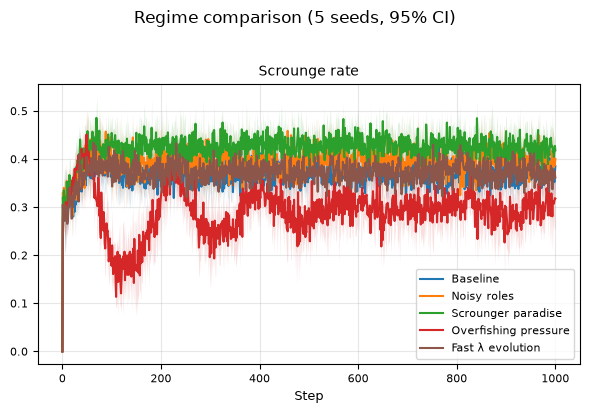

In [5]:
METRIC = "Scrounge rate"

fig, ax = plt.subplots(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 0.5, len(REGIMES)))

for color, regime in zip(colors, REGIMES):
    runs = results[regime["name"]]
    steps, mean, sem = _aggregate_runs(runs, [METRIC])
    m, h = mean[METRIC], sem[METRIC] * 1.96
    label = regime["name"].split(" · ", 1)[-1]
    ax.plot(steps, m, color=color, lw=1.5, label=label)
    ax.fill_between(steps, m - h, m + h, color=color, alpha=0.15, linewidth=0)

ax.set_title(METRIC, fontsize=10)
ax.set_xlabel("Step", fontsize=9)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, loc="best")

fig.suptitle(f"Regime comparison ({N_SEEDS} seeds, 95% CI)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()